## Imports

In [1]:
import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np

import cartopy.crs as ccrs

import sklearn

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


### Updates (temp)

In [2]:
importlib.reload(model.stats);
importlib.reload(model.shape_data);
importlib.reload(model.transform);



## Load Data

In [3]:
is_local_data = True
month_idx = 4
safe = False

In [4]:
mrsol_ds_for_mean = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)

mrsol_ds_for_var = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)

#Wenn man sicher gehen will, das der Predictor die testdaten nicht kennen soll, kann man die testdaten auch erst nach dem Calibrieren berechnen
mrsol_ds_for_test = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)


In [5]:
mrsol_empirical_maximas = mrsol_ds_for_mean.max("time")

mrsol_approx_1_maximas = mrsol_empirical_maximas.copy(deep=True)
mrsol_approx_1_maximas["mrsol"] = mrsol_empirical_maximas["mrsol"] * 1.1 + 1e-5

mrsol_approx_2_maximas = mrsol_empirical_maximas.copy(deep=True)
mrsol_approx_2_maximas["mrsol"] = np.maximum(mrsol_empirical_maximas["mrsol"] * 1.05,(mrsol_empirical_maximas["depth_bnds"].isel(bnds=1)-mrsol_empirical_maximas["depth_bnds"].isel(bnds=0))*1000*0.30)

mrsol_month_empirical_maximas = model.shape_data.prune_group_ds_timespan(mrsol_ds_for_mean,Month_idx=month_idx).max("time")
mrsol_month_empirical_maximas["mrsol"] = mrsol_month_empirical_maximas["mrsol"] * 1.1 + 1e-5



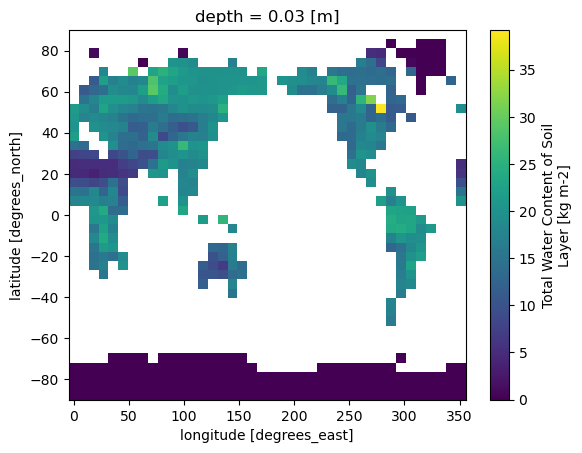

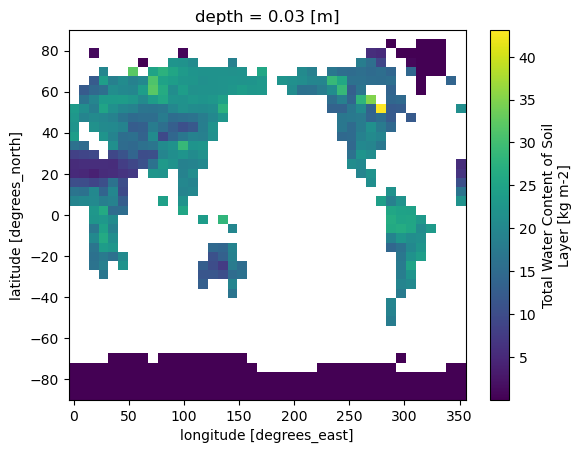

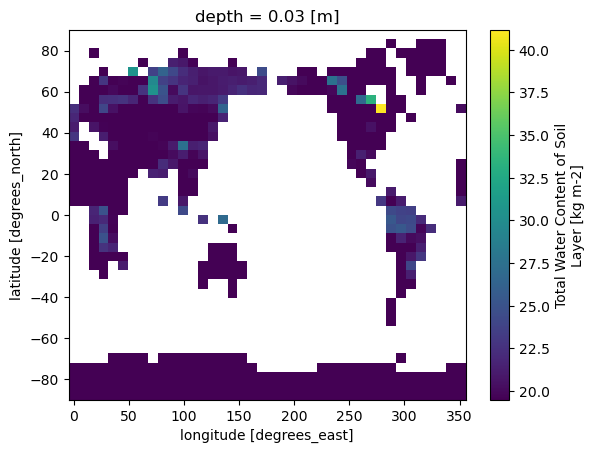

In [6]:
mrsol_empirical_maximas.isel(depth = 0).mrsol.plot(x="lon")
plt.show()
mrsol_approx_1_maximas.isel(depth = 0).mrsol.plot(x="lon")
plt.show()
mrsol_approx_2_maximas.isel(depth = 0).mrsol.plot(x="lon");
plt.show()
mrsol_maximas = mrsol_approx_2_maximas

In [7]:
mrsol_relative_ds_for_mean = mrsol_ds_for_mean.copy(deep=True)
mrsol_relative_ds_for_mean["mrsol"] = mrsol_relative_ds_for_mean["mrsol"]/mrsol_maximas["mrsol"]

mrsol_relative_ds_for_var = mrsol_ds_for_var.copy(deep=True)
mrsol_relative_ds_for_var["mrsol"] = mrsol_relative_ds_for_var["mrsol"]/mrsol_maximas["mrsol"]

mrsol_relative_ds_for_test = mrsol_ds_for_test.copy(deep=True)
mrsol_relative_ds_for_test["mrsol"] = mrsol_relative_ds_for_test["mrsol"]/mrsol_maximas["mrsol"]

In [8]:
mrsol_pruned_ds_for_mean = model.shape_data.prune_group_ds_timespan(mrsol_relative_ds_for_mean,Month_idx=month_idx)
mrsol_pruned_ds_for_var = model.shape_data.prune_group_ds_timespan(mrsol_relative_ds_for_var,Month_idx=month_idx)
mrsol_pruned_ds_for_test = model.shape_data.prune_group_ds_timespan(mrsol_relative_ds_for_test,Month_idx=month_idx)

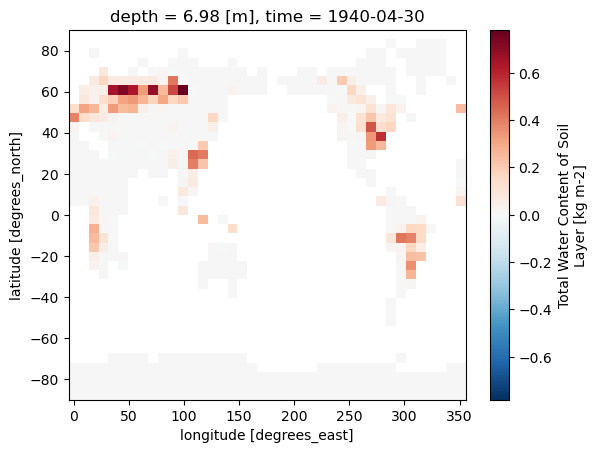

In [9]:
mrsol_pruned_ds_for_mean.isel(depth = 4).isel(time = 90).mrsol.plot(x="lon")

In [10]:
tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_mean = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_var = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=3)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=3)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### Mask and Stack Data

In [11]:
mrsol_masked_ds_for_mean, chunk_mask, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds_for_mean.drop_vars("depth_bnds"))
input_masked_ds_for_mean = model.mask.mask_mask(input_ds_for_mean,chunk_mask)

mrsol_masked_ds_for_var , chunk_mask_var, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds_for_var.drop_vars("depth_bnds"))
input_masked_ds_for_var = model.mask.mask_mask(input_ds_for_var,chunk_mask)

mrsol_masked_ds_for_test, chunk_mask_test, detail_mask_mean= model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds_for_test.drop_vars("depth_bnds"))
input_masked_ds_for_test = model.mask.mask_mask(input_ds_for_test,chunk_mask)

mrsol_maximas_masked = model.mask.mask_mask(mrsol_maximas,chunk_mask)

In [12]:
#The chunk_mask schould all be the same, this is important that there are no shape problems in the regressions, you can test this with  
#(chunk_mask != chunk_mask_2).sum(),#(chunk_mask != chunk_mask_1).sum(),
#The chunk_mask is used, that the regression can predict a depth.size vector at each gridcell, the masks: detail_mask_mean, detail_mask_var and detail_mask_test are later used to determan which points are real predictions and witch where just placeholders to let the regression run smoothly.

In [13]:
mrsol_stack_ds_for_mean = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_mean)
mrsol_stack_ds_for_var = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_var)
mrsol_stack_ds_for_test = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_test)
input_stack_ds_for_mean = mesmer.grid.stack_lat_lon(input_masked_ds_for_mean)
input_stack_ds_for_var = mesmer.grid.stack_lat_lon(input_masked_ds_for_var)
input_stack_ds_for_test = mesmer.grid.stack_lat_lon(input_masked_ds_for_test)
mrsol_maximas_stack = mesmer.grid.stack_lat_lon(mrsol_maximas_masked)

### Transform Data

In [14]:
#Normierung, da Betaverteilung zwischen 0 und 1 gefittet wird (für Betaverteilung sollte die Transformation vor dro vars depth bnds, mask und stack sitzen)
#porosität von 0.35 bis 0.6 annehmen
#schauen ob es Modelle hat mit ähnlicher datenstruktur aber mit porösität?

In [15]:
mrsol_t_for_mean = model.transform.none_Transform_ds(mrsol_stack_ds_for_mean)
mrsol_t_for_var = model.transform.none_Transform_ds(mrsol_stack_ds_for_var)
mrsol_t_for_test = model.transform.none_Transform_ds(mrsol_stack_ds_for_test)

### Linear Regression of the mean

In [16]:
mean_predictors = input_stack_ds_for_mean
mean_target_da = mrsol_t_for_mean.mrsol

In [17]:
LinReg_mean = model.stats._parallel_linear_regression.ParLinearRegression()

In [18]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

In [19]:
#LinReg_mean.params

### Compute Residuals for the variance

Hier wäre die meinung einen neuen Run zu verwenden, die frage ist ob sich die variance durch das fehlen des runs zu tief ausfällt. Overfitting korrektur mit 1/(1-param/n_samples)^2? (Später probieren)

In [20]:
var_predictors = input_stack_ds_for_var
var_target_ds = mrsol_t_for_var

In [21]:
var_predictors.isel(gridcell = 170).to_array().T

<xarray.DataArray (time: 165, variable: 2)> Size: 3kB
array([[2.85978662e+02, 7.13227485e-05],
       [2.87906547e+02, 7.29410021e-05],
       [2.87037974e+02, 7.13594501e-05],
       [2.83832134e+02, 7.67112810e-05],
       [2.85887978e+02, 7.24547942e-05],
       [2.84153072e+02, 4.45136888e-05],
       [2.87805446e+02, 5.98322191e-05],
       [2.84526056e+02, 5.44704871e-05],
       [2.83689236e+02, 5.07542746e-05],
       [2.88236678e+02, 2.91769268e-05],
       [2.83567583e+02, 8.48496087e-05],
       [2.88052647e+02, 5.66587996e-05],
       [2.83686797e+02, 6.02866656e-05],
       [2.84122768e+02, 7.30285310e-05],
       [2.85355529e+02, 2.21252865e-05],
       [2.87131190e+02, 5.53318779e-05],
       [2.88207559e+02, 8.50867818e-05],
       [2.86299042e+02, 4.72513701e-05],
       [2.88150200e+02, 4.13707940e-05],
       [2.85693297e+02, 7.83610625e-05],
...
       [2.83647639e+02, 6.26658847e-05],
       [2.86548972e+02, 4.51834052e-05],
       [2.86563591e+02, 7.51809398e-05],
       [2.86437324e+02, 3.69818379e-05],
       [2.85873439e+02, 5.69060454e-05],
       [2.86228408e+02, 7.25134270e-05],
       [2.85389719e+02, 4.22899352e-05],
       [2.87245201e+02, 3.08394021e-05],
       [2.84999184e+02, 7.55239498e-05],
       [2.85621214e+02, 4.23461400e-05],
       [2.85745555e+02, 4.29427136e-05],
       [2.86956042e+02, 1.26249386e-04],
       [2.84286875e+02, 5.09195658e-05],
       [2.86723018e+02, 6.82825399e-05],
       [2.84027388e+02, 6.85933920e-05],
       [2.83607882e+02, 3.88220956e-05],
       [2.84431168e+02, 7.33229403e-05],
       [2.88583049e+02, 4.17698855e-05],
       [2.85933851e+02, 3.37664532e-05],
       [2.85873187e+02, 6.23406945e-05]])
Coordinates:
  * time      (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
  * variable  (variable) object 16B 'tas' 'pr'
    height    float64 8B 2.0
    lat       float64 8B 33.75
    lon       float64 8B 117.0
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:10 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/1e556aad-382b-474a-b282-59c8bf9b6421
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  ccbabc2709d37dde96079a7fd7e7e91fb74d6d4785fbbe...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [22]:
var_target_ds.isel(gridcell=170).isel(depth = 0).mrsol.values

array([0.74814824, 0.81602825, 0.81234714, 0.84907924, 0.83035888,
       0.80515849, 0.76229604, 0.82230745, 0.82508539, 0.71501477,
       0.86701607, 0.81792639, 0.86410318, 0.87188778, 0.6932938 ,
       0.82922035, 0.85437985, 0.73124094, 0.78644707, 0.83195308,
       0.85455869, 0.59444587, 0.72359123, 0.74368899, 0.46496095,
       0.67918301, 0.68212309, 0.81052877, 0.61405523, 0.75740657,
       0.68695296, 0.90473573, 0.70660133, 0.87798405, 0.50834275,
       0.84562994, 0.73526868, 0.7950823 , 0.82301975, 0.79490863,
       0.64935745, 0.76668239, 0.78417675, 0.86583838, 0.77604471,
       0.88055907, 0.80662154, 0.71904859, 0.52778381, 0.67550824,
       0.73574972, 0.88882892, 0.73948062, 0.84427748, 0.80058133,
       0.64441185, 0.72245143, 0.82815253, 0.7975346 , 0.79832476,
       0.84827537, 0.85247812, 0.89394181, 0.81498419, 0.89141211,
       0.73574565, 0.7596312 , 0.61983776, 0.62496734, 0.64238325,
       0.7690482 , 0.7667436 , 0.66309167, 0.84078789, 0.88738

In [23]:
"""
training_data = var_predictors.isel(gridcell = 170).to_array().T
labels = var_target_ds.isel(gridcell=170).isel(depth = 0).mrsol.values # Example quadratic relationship: y = x^2

# Define polynomial features for interaction terms only and without bias term
poly = PolynomialFeatures(include_bias=False)
#model = sklearn.linear_model.LinearRegression()

# Transform training data to include polynomial features and fit the model
poly_features = poly.fit_transform(training_data)
#model.fit(poly_features, labels)

# Define sample test data
test_data = np.array(var_predictors.isel(gridcell = 170).isel(time = slice(0,5)).to_array().T)

# Transform test data with the same 'PolynomialFeatures' instance and predict labels
test_poly_features = poly.transform(test_data)
predictions = model.predict(test_poly_features)

print(predictions)
LinearRegression.get_params()
#model.coef_
"""

"\ntraining_data = var_predictors.isel(gridcell = 170).to_array().T\nlabels = var_target_ds.isel(gridcell=170).isel(depth = 0).mrsol.values # Example quadratic relationship: y = x^2\n\n# Define polynomial features for interaction terms only and without bias term\npoly = PolynomialFeatures(include_bias=False)\n#model = sklearn.linear_model.LinearRegression()\n\n# Transform training data to include polynomial features and fit the model\npoly_features = poly.fit_transform(training_data)\n#model.fit(poly_features, labels)\n\n# Define sample test data\ntest_data = np.array(var_predictors.isel(gridcell = 170).isel(time = slice(0,5)).to_array().T)\n\n# Transform test data with the same 'PolynomialFeatures' instance and predict labels\ntest_poly_features = poly.transform(test_data)\npredictions = model.predict(test_poly_features)\n\nprint(predictions)\nLinearRegression.get_params()\n#model.coef_\n"

In [24]:
0.74814824, 0.81602825, 0.81234714, 0.84907924, 0.83035888,

(0.74814824, 0.81602825, 0.81234714, 0.84907924, 0.83035888)

In [25]:
#LinearRegression = sklearn.preprocessing.PolynomialFeatures(degree=2)
#model = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None, positive=False)

In [26]:
residuals_t = LinReg_mean.residuals(var_predictors, var_target_ds)

In [27]:
residuals_t

<xarray.Dataset> Size: 2MB
Dimensions:    (depth: 5, time: 165, gridcell: 377)
Coordinates:
  * depth      (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time       (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    lat        (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon        (gridcell) float64 3kB 288.0 288.0 288.0 ... 99.0 270.0 279.0
    height     float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    residuals  (time, depth, gridcell) float64 2MB 0.003485 ... 2.711e-19

### Poly Regression of the Variance

In [28]:
importlib.reload(model.stats._parallel_polynomial_regression);
from model.stats._parallel_polynomial_regression import ParPolyRegression
PolyReg_variance = model.stats.ParPolyRegression(degree=2)

In [29]:
PolyReg_variance.fit(predictors=var_predictors, target=(residuals_t.residuals)**2,location_dim="gridcell", regr_dim="time")

['tas' 'pr']


### Predictor

In [30]:
#LinReg_mean.params

In [31]:
#PolyReg_variance.params

In [32]:
LinReg_mean, PolyReg_variance

(<model.stats._parallel_linear_regression.ParLinearRegression at 0x7fb408286f90>,
 <model.stats._parallel_polynomial_regression.ParPolyRegression at 0x7fb408286e40>)

### Export Prameters

In [33]:
if False:
    model.save.save_params(LinReg_mean.params,LinReg_variance.params,var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log_transform", name=f"month_idx= {month_idx}")

In [34]:
#model.shape_data.load_params(var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log_transform")

### Example Emulation

In [35]:
test_predictors = input_stack_ds_for_test
test_target_ds_t = mrsol_t_for_test.transpose("gridcell","time", "depth")

In [36]:
test_mean_prediction_stacked = LinReg_mean.predict(test_predictors).transpose("gridcell","time", "depth")

In [37]:
"""
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit([[0] * len(list(["tas","pr"]))])
print(list(poly.get_feature_names_out(list(["tas","pr"]))))
"""

'\nfrom sklearn.preprocessing import PolynomialFeatures\npoly = PolynomialFeatures(degree=2, include_bias=False)\npoly.fit([[0] * len(list(["tas","pr"]))])\nprint(list(poly.get_feature_names_out(list(["tas","pr"]))))\n'

In [38]:
#test_predictors

In [39]:
#poly.fit_transform(test_predictors.to_array().transpose("gridcell","time","variable").values.reshape(-1,len(test_predictors.data_vars)))

In [40]:
test_var_prediction_stacked = PolyReg_variance.predict(test_predictors)#.clip(min = 1e-32).transpose("gridcell","time", "depth")

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 165, gridcell: 377)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    lat      (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon      (gridcell) float64 3kB 288.0 288.0 288.0 144.0 ... 99.0 270.0 279.0
    height   float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    tas      (time, gridcell) float64 498kB 277.3 277.2 280.0 ... 255.6 254.0
    pr       (time, gridcell) float64 498kB 4.013e-05 6.688e-05 ... 5.841e-06
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:24 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                      

In [64]:
test_var_prediction_stacked

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 165, gridcell: 377, depth: 5)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    lat         (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75
    lon         (gridcell) float64 3kB 288.0 288.0 288.0 ... 99.0 270.0 279.0
  * depth       (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
    height      float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    prediction  (depth, gridcell, time) float64 2MB 0.0001485 ... 7.347e-38

In [41]:
from sklearn.preprocessing import PolynomialFeatures                            #in the middle of the code as in mesmer LinearRegression
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit([[0] * len(list(["tas","pr"]))])

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [42]:
"""
        # default case: use all predictors in data_vars
        non_predictor_vars = {"intercept", "weights", "fit_intercept"}
        available_params = set(params.data_vars) - non_predictor_vars
        available_predictors = set(predictors.keys())

                                                                         #in the middle of the code as in mesmer LinearRegression
                                                                          
        from sklearn.preprocessing import PolynomialFeatures
        poly = PolynomialFeatures(degree=2, include_bias=False)
        poly.fit([[0] * len(list([available_predictors]))])

        print(list(poly.get_feature_names_out(list(predictors.coords["predictor"].values))))
        # the default (`exclude` or `only` is not used)
        use_intercept = True
        used_predictors = available_params
        superfluous = available_predictors - used_predictors"""

'\n        # default case: use all predictors in data_vars\n        non_predictor_vars = {"intercept", "weights", "fit_intercept"}\n        available_params = set(params.data_vars) - non_predictor_vars\n        available_predictors = set(predictors.keys())\n\n                                                                         #in the middle of the code as in mesmer LinearRegression\n\n        from sklearn.preprocessing import PolynomialFeatures\n        poly = PolynomialFeatures(degree=2, include_bias=False)\n        poly.fit([[0] * len(list([available_predictors]))])\n\n        print(list(poly.get_feature_names_out(list(predictors.coords["predictor"].values))))\n        # the default (`exclude` or `only` is not used)\n        use_intercept = True\n        used_predictors = available_params\n        superfluous = available_predictors - used_predictors'

In [43]:
test_var_prediction_stacked

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 165, gridcell: 377, depth: 5)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    lat         (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75
    lon         (gridcell) float64 3kB 288.0 288.0 288.0 ... 99.0 270.0 279.0
  * depth       (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
    height      float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    prediction  (depth, gridcell, time) float64 2MB 0.0001485 ... 7.347e-38

In [65]:
set(test_var_prediction_stacked.keys())

{'prediction'}

### crps(s) Score

In [66]:
#temp
importlib.reload(model_analysis.crps_score);

In [67]:
mean = test_mean_prediction_stacked.copy(deep=True)
var = test_var_prediction_stacked.copy(deep=True)

#todo precision parameter in guter Quelle finden
precision = (mean*(1-mean))/var-1

test_alpha_prediction_stacked = mean*precision
test_beta_prediction_stacked = (1-mean)*precision

In [68]:
maximas = mrsol_maximas_stack.drop_vars("depth_bnds").transpose("gridcell","depth")


In [69]:
maximas

<xarray.Dataset> Size: 21kB
Dimensions:  (depth: 5, gridcell: 377)
Coordinates:
  * depth    (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
    lat      (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon      (gridcell) float64 3kB 288.0 288.0 288.0 144.0 ... 99.0 270.0 279.0
Dimensions without coordinates: gridcell
Data variables:
    mrsol    (gridcell, depth) float64 15kB 19.5 76.2 273.9 ... 870.6 1.71e+03
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [70]:
test_alpha_prediction_stacked

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 165, gridcell: 377, depth: 5)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    lat         (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75
    lon         (gridcell) float64 3kB 288.0 288.0 288.0 ... 99.0 270.0 279.0
  * depth       (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
    height      float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    prediction  (gridcell, time, depth) float64 2MB 901.3 529.2 ... 1.361e+29

scheinbar wächst die laufzeit in der ensemble_size mehr als linear, sieht schlimmer als quadratisch aus:(

5->0.5s

10->1.3s

20->4.2s

40->15s

80->1min 54s

In [71]:
crps_score_stacked, space_crps_score_stacked = model_analysis.crps_score.crps_beta_ensemble_score(test_alpha_prediction_stacked.isel(depth=slice(0,3)).clip(min=1e-32), test_beta_prediction_stacked.isel(depth=slice(0,3)).clip(min=1e-32),test_target_ds_t.isel(depth=slice(0,3)),transformation="rel",mrsol_maximas=maximas,ensemble_size=15)

for both of the scors we can calculate a crpss score against the time constant mean, for the score of the backtransposed data, we need to make a non-transposed target.

In [72]:

test_target_ds = test_target_ds_t.copy(deep=True) 
test_target_ds["mrsol"] = test_target_ds_t["mrsol"] * maximas["mrsol"]


In [73]:
scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(crps_score_stacked,test_target_ds) 

In [74]:
space_scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(space_crps_score_stacked,test_target_ds_t) 

To visualize the results we bring it back to the lat lon grid form. Ausserdem entnehmen wir die Stellen wieder, die mit threshholds aufgefüllt wurden

In [75]:
scores = mesmer.grid.unstack_lat_lon_and_align(scores_stacked,mrsol_masked_ds_for_mean.isel(depth=slice(0,2)))
space_scores = mesmer.grid.unstack_lat_lon_and_align(space_scores_stacked,mrsol_masked_ds_for_mean.isel(depth=slice(0,2)))

In [76]:
scores = model.mask.mask_mask(scores,detail_mask_mean, "lon","lat", "depth")
space_scores = model.mask.mask_mask(space_scores,detail_mask_mean, "lon","lat", "depth")

In [77]:
scores.isel(lat=21,lon=32,depth=0).mean("time").crps_score


<xarray.DataArray 'crps_score' ()> Size: 8B
array(0.30814961)
Coordinates:
    lon      float64 8B 288.0
    lat      float64 8B 6.75
    depth    float64 8B 0.03

Globale Score übersicht

Text(0.5, 1.0, 'crpss_score against const mean')

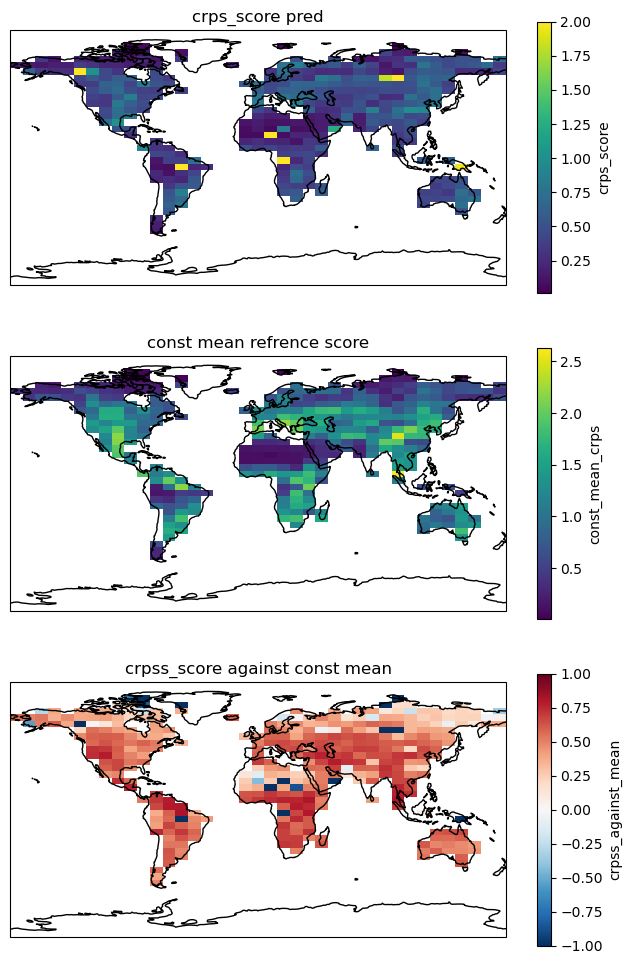

In [78]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)
depth = 0

da = scores.isel(depth=depth).mean("time").crps_score.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = scores.isel(depth=depth).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = scores.isel(depth=depth).mean("time").crpss_against_mean.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")



Text(0.5, 1.0, 'space_crpss_score against const mean')

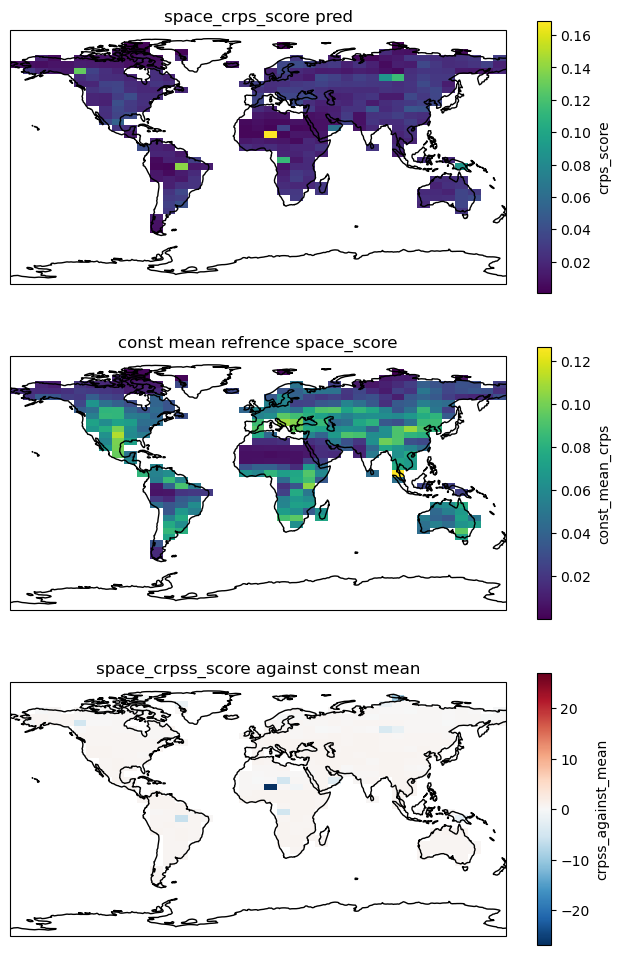

In [58]:
fig_global_space_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)

da = space_scores.isel(depth=0).mean("time").crps_score
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("space_crps_score pred")

da = space_scores.isel(depth=0).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence space_score")

da = space_scores.isel(depth=0).mean("time").crpss_against_mean
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("space_crpss_score against const mean")



Locale Zeit reihe

In [59]:
#Amazonas  ca. 3° S, 65° W

In [60]:
#scores.sel(lat= -3, lon = 295, method="nearest").isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

In [61]:
#irgendwo in Russland

In [62]:
#scores.sel(lat= 60, lon = 100, method="nearest").isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

### Save results

In [63]:
if safe:
    model.save.save_crps_scores(space_scores, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name=f"approx_mon_emp11_month_idx = {month_idx}",name_postfix="")
    model.save.save_crps_scores(scores, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist",name=f"approx_mon_emp11_month_idx = {month_idx}", name_postfix="back_transformed")
    model.save.save_plot(fig_global_crpss, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name = f"fig_global_crpss_clipped_month_idx = {month_idx}_approx_mon_emp11")
    model.save.save_plot(fig_global_space_crpss, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name = f"fig_global_space_crpss__month_idx = {month_idx}_approx_mon_emp11")